# ⚡ Spike Detection using XGBoost Classifier

This notebook performs binary time series classification to detect future transaction fee spikes. It includes:
- Binary spike labeling
- Lagged and contextual features
- Hyperparameter-tuned XGBoost Classifier
- Evaluation with confusion matrix and scores
- Baseline comparison with a dummy classifier


In [6]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# Load preprocessed data
df = pd.read_parquet('../data/processed/preprocessed_xgboost.parquet')
df.dropna(inplace=True)

# Add lagged features
def add_selected_lags(df, columns, lags=[1, 2, 3, 6, 12]):
    lagged_cols = []
    for col in columns:
        for lag in lags:
            shifted = df[col].shift(lag)
            shifted.name = f"{col}_lag_{lag}"
            lagged_cols.append(shifted)
    df_lags = pd.concat(lagged_cols, axis=1)
    df_combined = pd.concat([df, df_lags], axis=1)
    return df_combined

target_col = "recommended_fee_fastestFee"
exog_cols = [col for col in df.columns if col != target_col and "mempool_fee_histogram_bin" not in col]
df_lagged = add_selected_lags(df.copy(), columns=exog_cols)
df_lagged.dropna(inplace=True)


In [8]:
# Create binary spike target
horizon = 288  # e.g., 24 hours ahead
threshold = 5
df_lagged["spike"] = (df_lagged[target_col].shift(-horizon) > threshold).astype(int)
df_lagged.dropna(inplace=True)

X = df_lagged.drop(columns=[target_col, "spike"])
y = df_lagged["spike"]

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)


In [9]:
# Hyperparameter tuning for XGBClassifier
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "n_estimators": [100, 200],
    "subsample": [0.7, 1.0],
    "scale_pos_weight": [imbalance_ratio, imbalance_ratio * 2]
}

xgb = XGBClassifier(eval_metric="logloss")
search = RandomizedSearchCV(xgb, param_distributions=param_grid, cv=3, scoring="f1", n_iter=10, verbose=1)
search.fit(X_train, y_train)
best_model = search.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits


Confusion Matrix:
[[1112   76]
 [  91    1]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9244    0.9360    0.9302      1188
           1     0.0130    0.0109    0.0118        92

    accuracy                         0.8695      1280
   macro avg     0.4687    0.4734    0.4710      1280
weighted avg     0.8589    0.8695    0.8642      1280



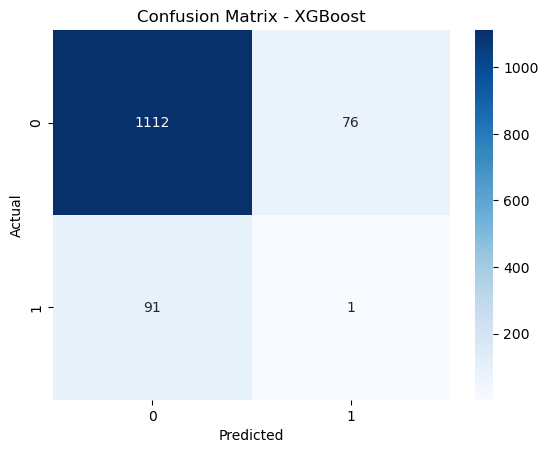

In [10]:
# Predict and evaluate
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()


In [11]:
# Dummy baseline (most frequent)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

print("Dummy Classifier Report:")
print(classification_report(y_test, y_dummy, digits=4))

# Score comparison
xgb_scores = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0)
}

dummy_scores = {
    "accuracy": accuracy_score(y_test, y_dummy),
    "precision": precision_score(y_test, y_dummy, zero_division=0),
    "recall": recall_score(y_test, y_dummy, zero_division=0),
    "f1": f1_score(y_test, y_dummy, zero_division=0)
}

comparison_df = pd.DataFrame([xgb_scores, dummy_scores], index=["XGBoost", "Dummy"])
comparison_df


Dummy Classifier Report:
              precision    recall  f1-score   support

           0     0.9281    1.0000    0.9627      1188
           1     0.0000    0.0000    0.0000        92

    accuracy                         0.9281      1280
   macro avg     0.4641    0.5000    0.4814      1280
weighted avg     0.8614    0.9281    0.8935      1280



c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

,accuracy,precision,recall,f1
XGBoost,0.869531,0.012987,0.01087,0.011834
Dummy,0.928125,0.000000,0.00000,0.000000


In [12]:
# 🔄 Rolling prediction on last 24 hours (288 steps)
# Retrain on full 80% training set using best hyperparameters
final_model = search.best_estimator_
final_model.fit(X_train, y_train)

# Use the final 288 rows of the test set
rolling_window = 288
X_rolling = X_test.tail(rolling_window)
y_rolling_true = y_test.tail(rolling_window)
y_rolling_pred = final_model.predict(X_rolling)

# Evaluate on rolling prediction
from sklearn.metrics import confusion_matrix, classification_report

print("Rolling Prediction (Last 24 Hours):")
print(confusion_matrix(y_rolling_true, y_rolling_pred))
print(classification_report(y_rolling_true, y_rolling_pred, digits=4))


Rolling Prediction (Last 24 Hours):
[[287   1]
 [  0   0]]
              precision    recall  f1-score   support

           0     1.0000    0.9965    0.9983       288
           1     0.0000    0.0000    0.0000         0

    accuracy                         0.9965       288
   macro avg     0.5000    0.4983    0.4991       288
weighted avg     1.0000    0.9965    0.9983       288



c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
